In [26]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

In [27]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [28]:
X

array([[ -2.93897827,  -9.11204192],
       [  2.33915693,  -0.46051582],
       [ -4.07606101, -11.44761443],
       ...,
       [ -2.5206105 ,  -9.84606144],
       [  2.20603238,  -1.07299079],
       [  2.70207683,  -1.49886218]], shape=(1000, 2))

In [29]:
y

array([0, 1, 0, 1, 1, 0, 2, 2, 2, 0, 2, 0, 2, 1, 1, 1, 2, 0, 2, 0, 1, 2,
       0, 2, 1, 1, 0, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 0, 0, 2, 2, 1, 0, 0,
       0, 2, 1, 0, 1, 2, 2, 1, 2, 2, 0, 2, 2, 1, 2, 0, 1, 0, 0, 2, 1, 2,
       1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 2, 1, 0, 2, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 2, 2, 1, 2, 2, 2, 0, 0, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 2, 0, 2, 0, 2, 1, 0, 2, 1, 1, 0, 0, 0, 0, 0, 2, 2,
       1, 0, 2, 0, 1, 1, 0, 2, 2, 1, 1, 1, 0, 2, 0, 2, 0, 0, 0, 1, 1, 1,
       1, 2, 1, 2, 0, 1, 1, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0,
       2, 1, 1, 2, 0, 0, 0, 0, 0, 1, 2, 1, 2, 0, 1, 0, 1, 0, 0, 2, 0, 2,
       0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 0, 1, 2, 1, 2, 1, 1,
       2, 2, 2, 2, 2, 0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 2, 1, 1, 2, 2,
       1, 0, 0, 1, 1, 2, 1, 1, 2, 0, 2, 1, 0, 1, 1, 1, 0, 2, 2, 1, 2, 2,
       1, 2, 2, 1, 1, 2, 0, 0, 1, 2, 0, 1, 1, 2, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 2, 1, 1, 0, 2, 1, 2, 2, 2, 0, 1, 2, 0,

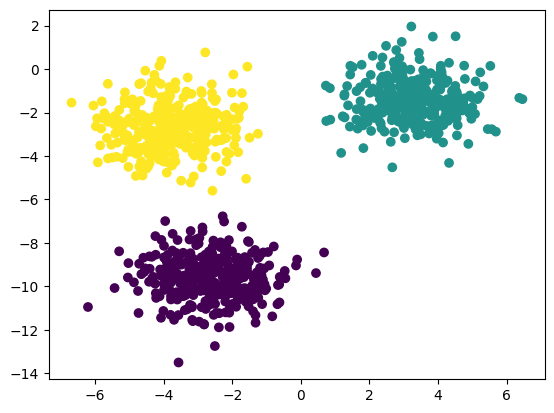

In [30]:
plt.scatter(X[:,0], X[:,1], c=y)

In [31]:
## Standardization-- feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.cluster import KMeans

In [35]:
# Elbow method to select the K Value

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)


In [36]:
wcss

[1339.9999999999998,
 496.97085782276775,
 112.8185129660796,
 98.62006261153537,
 85.27810178544016,
 71.05830423177845,
 65.98508491637443,
 58.614885229314226,
 53.36195162859197,
 50.88234509813013]

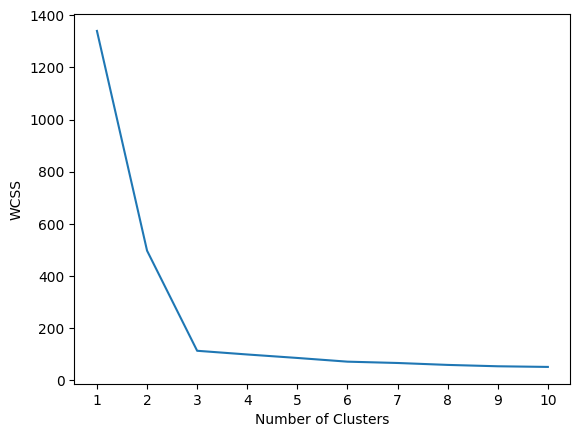

In [37]:
# plot elbow curve

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [38]:
kmeans = KMeans(n_clusters=3, init="k-means++")

In [39]:
kmeans.fit_predict(X_train_scaled)

array([2, 2, 1, 0, 2, 1, 2, 0, 0, 1, 1, 2, 0, 2, 2, 2, 1, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 1, 0, 1, 2, 2, 0, 2, 2, 1, 0, 2,
       0, 1, 1, 0, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 2, 2, 1, 1, 1, 2, 0, 0,
       1, 0, 0, 2, 1, 1, 2, 2, 0, 2, 1, 0, 1, 0, 1, 1, 1, 1, 2, 0, 2, 0,
       1, 2, 0, 0, 2, 1, 0, 2, 1, 2, 0, 1, 1, 2, 0, 0, 2, 0, 2, 0, 1, 2,
       0, 2, 0, 1, 1, 1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 0, 1, 1, 1, 1,
       2, 1, 1, 2, 1, 1, 1, 0, 1, 0, 2, 0, 0, 0, 1, 2, 0, 1, 0, 0, 2, 0,
       1, 2, 2, 1, 0, 1, 1, 0, 1, 2, 1, 1, 1, 1, 0, 2, 2, 1, 0, 2, 2, 0,
       1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 0, 2, 2, 2, 1, 0, 1, 2, 1, 2, 2,
       1, 0, 0, 1, 1, 2, 1, 0, 1, 0, 1, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 0, 1, 0, 2, 2, 1, 1, 0, 0, 1, 1, 2, 0, 0, 2, 1, 2, 1, 2, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 2, 2, 1, 1, 1, 0, 0, 2, 2, 2, 1, 1, 1, 0,
       0, 1, 2, 0, 0, 0, 2, 2, 0, 1, 2, 0, 1, 0, 0, 2, 2, 1, 0, 0, 1, 0,
       0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 2, 0, 1,

In [40]:
y_pred = kmeans.predict(X_test_scaled)

In [41]:
y_pred

array([0, 0, 2, 0, 2, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 2, 0,
       2, 0, 1, 2, 0, 1, 0, 1, 0, 0, 2, 2, 0, 2, 2, 2, 1, 2, 2, 2, 0, 0,
       0, 0, 2, 0, 1, 1, 2, 1, 1, 2, 0, 2, 2, 0, 0, 1, 0, 2, 2, 0, 0, 1,
       1, 0, 1, 2, 2, 1, 0, 2, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 2, 0, 2, 2, 1, 1, 0, 1, 2, 0, 2, 1, 1, 0, 1, 0, 1, 0, 2, 2, 2,
       2, 2, 2, 0, 1, 2, 2, 0, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 1,
       0, 2, 0, 0, 1, 0, 1, 1, 2, 0, 0, 1, 2, 2, 1, 2, 2, 0, 0, 2, 1, 1,
       1, 1, 0, 1, 1, 2, 1, 0, 1, 1, 2, 2, 1, 2, 2, 0, 2, 0, 2, 0, 0, 2,
       2, 0, 1, 1, 1, 2, 1, 2, 0, 1, 2, 0, 1, 1, 1, 0, 0, 2, 2, 2, 1, 0,
       2, 2, 0, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 1, 1, 0, 1,
       0, 0, 2, 0, 2, 2, 0, 1, 1, 1, 0, 0, 2, 2, 2, 2, 1, 1, 1, 0, 1, 1,
       2, 2, 2, 2, 0, 1, 1, 2, 2, 0, 1, 2, 2, 0, 2, 1, 0, 2, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 2, 0, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0,
       1, 2, 2, 1, 1, 2, 1, 0, 0, 1, 0, 1, 0, 0, 2,

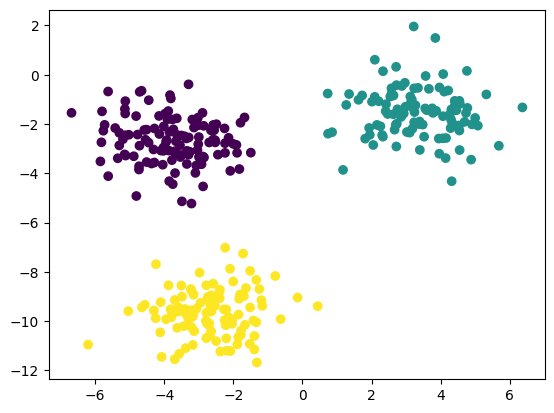

In [42]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)

In [43]:
# Validating the k value we use 2 techniques
# 1.kneeLocator
# 2.Silhoutee scoring

In [44]:
## kneeLocator
!pip install kneed

In [45]:
from kneed import KneeLocator

In [47]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [48]:
kl.elbow

np.int64(3)

In [49]:
## 2. silhoutte scoring
from sklearn.metrics import silhouette_score

In [50]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [51]:
silhouette_coefficients

[0.6071179402732825,
 0.7349307634476517,
 0.5764415696230479,
 0.4617788465704376,
 0.33929391292602007,
 0.34907381336071475,
 0.35191791646815146,
 0.3394302762477227,
 0.3552011476926671]

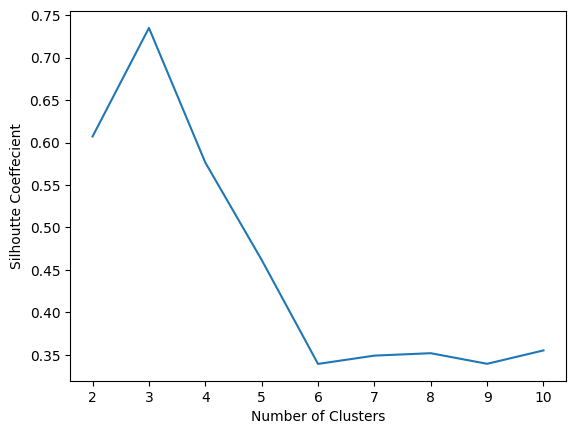

In [53]:
# Plotting Silhoutte score

plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

### Observation
 -  k value should be 3 , because increase in silhoutte score 